In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"../data/processed/startup_phase1.csv")

In [31]:
# How many startups are present in our dataset?
df.shape

(66368, 16)

In [32]:
# How many features (columns) are available?
df.shape[1]

16

In [33]:
# What information does each feature contain?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   permalink           66368 non-null  object        
 1   name                66367 non-null  object        
 2   category_list       63220 non-null  object        
 3   funding_total_usd   53583 non-null  float64       
 4   status              66368 non-null  object        
 5   country_code        59410 non-null  object        
 6   state_code          57821 non-null  object        
 7   region              58338 non-null  object        
 8   city                58340 non-null  object        
 9   funding_rounds      66368 non-null  int64         
 10  founded_at          51143 non-null  datetime64[ns]
 11  first_funding_at    66341 non-null  datetime64[ns]
 12  last_funding_at     66368 non-null  datetime64[ns]
 13  founded_year        51143 non-null  float64   

In [43]:
# What do the first five startup records look like?
df.head()

,permalink,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,founded_year,first_funding_year,last_funding_year
0,/organization/-fame,#fame,Media,10000000.0,operating,IND,16,Mumbai,Mumbai,1,NaT,2015-01-05,2015-01-05,NaN,2015.0,2015
1,/organization/-qounter,:Qounter,Application Platforms|Real Time|Social Network...,700000.0,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14,2014.0,2014.0,2014
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878.0,operating,NaN,NaN,NaN,NaN,1,NaT,2014-01-30,2014-01-30,NaN,2014.0,2014
3,/organization/0-6-com,0-6.com,Curated Web,2000000.0,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19,2007.0,2008.0,2008
4,/organization/004-technologies,004 Technologies,Software,NaN,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24,2010.0,2014.0,2014


In [34]:
date_columns = [
    "founded_at",
    "first_funding_at",
    "last_funding_at"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column],errors="coerce")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   permalink           66368 non-null  object        
 1   name                66367 non-null  object        
 2   category_list       63220 non-null  object        
 3   funding_total_usd   53583 non-null  float64       
 4   status              66368 non-null  object        
 5   country_code        59410 non-null  object        
 6   state_code          57821 non-null  object        
 7   region              58338 non-null  object        
 8   city                58340 non-null  object        
 9   funding_rounds      66368 non-null  int64         
 10  founded_at          51143 non-null  datetime64[ns]
 11  first_funding_at    66341 non-null  datetime64[ns]
 12  last_funding_at     66368 non-null  datetime64[ns]
 13  founded_year        51143 non-null  float64   

In [44]:
# What are the different startup outcomes present in our dataset?
df["status"].unique()

array(['operating', 'acquired', 'closed', 'ipo'], dtype=object)

In [45]:
# How many different startup outcomes exist?
df["status"].nunique()

4

In [46]:
# How many startups belong to each outcome?
df["status"].value_counts()

status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

In [47]:
# What percentage of startups belongs to each outcome?
df["status"].value_counts(normalize=True).mul(100).round(2)

status
operating    79.91
closed        9.40
acquired      8.36
ipo           2.33
Name: proportion, dtype: float64

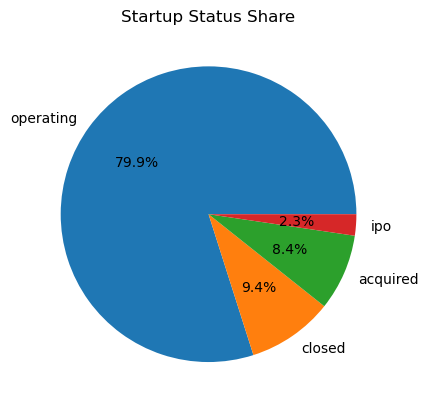

In [48]:
# visualize the startup outcomes
df["status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Startup Status Share")

plt.show()


# Observation
- Operating startups dominate the dataset.
- Closed startups represent only a small proportion.
- IPO and Acquired startups are relatively rare.


In [ ]:
# Is the dataset balanced? What does this mean for Machine Learning?
# A naïve model could simply predict "Operating" for almost every startup and still achieve high accuracy. That looks good numerically, but it fails at the actual business objective—identifying startups at risk. This is called class imbalance.
# The classes are not equally distributed.


In [40]:
# Can we directly train the model now?
# No

In [49]:
# How many countries are represented in our dataset?
df["country_code"].nunique()

137

In [50]:
# Which countries are present in the dataset?
df["country_code"].unique()

array(['IND', 'USA', nan, 'CHN', 'HKG', 'CAN', 'CHL', 'GBR', 'FRA', 'AUS',
       'DNK', 'ROM', 'AUT', 'KOR', 'NLD', 'SWE', 'JPN', 'RUS', 'SGP',
       'NOR', 'COL', 'ESP', 'BEL', 'IRL', 'ITA', 'ISR', 'NZL', 'CZE',
       'DEU', 'CHE', 'BRA', 'BGR', 'SVN', 'JOR', 'HUN', 'BWA', 'NGA',
       'FIN', 'TUR', 'IDN', 'ARE', 'CYP', 'POL', 'CRI', 'PRT', 'ARG',
       'TWN', 'KHM', 'THA', 'SVK', 'UKR', 'LTU', 'ISL', 'ZAF', 'MEX',
       'VEN', 'URY', 'MUS', 'KEN', 'PHL', 'MNE', 'VNM', 'GHA', 'PSE',
       'MYS', 'PER', 'EGY', 'PAN', 'LVA', 'GGY', 'ALB', 'UGA', 'HRV',
       'EST', 'LBN', 'GRC', 'PAK', 'NPL', 'LUX', 'SAU', 'IRN', 'GTM',
       'BAH', 'ARM', 'BGD', 'MDA', 'SRB', 'TUN', 'ZWE', 'BRB', 'NIC',
       'TAN', 'PRI', 'TTO', 'BHR', 'CMR', 'BLR', 'CYM', 'BRN', 'ECU',
       'SLV', 'MLT', 'ZMB', 'MKD', 'GIB', 'TGO', 'LAO', 'BMU', 'HND',
       'MCO', 'MMR', 'KAZ', 'QAT', 'DOM', 'MAR', 'LIE', 'GEO', 'MOZ',
       'DZA', 'JAM', 'KNA', 'AZE', 'SEN', 'RWA', 'DMA', 'UZB', 'BLZ',
       'OMN', '

In [51]:
# Which countries have the highest number of startups?
df["country_code"].value_counts().head(10)

country_code
USA    37601
GBR     3688
CAN     1925
IND     1596
CHN     1544
FRA     1135
DEU     1082
ISR      965
ESP      746
AUS      503
Name: count, dtype: int64

In [52]:
# What percentage of startups belongs to each country?
df["country_code"].value_counts(normalize=True).mul(100).round(2).head(10)

country_code
USA    63.29
GBR     6.21
CAN     3.24
IND     2.69
CHN     2.60
FRA     1.91
DEU     1.82
ISR     1.62
ESP     1.26
AUS     0.85
Name: proportion, dtype: float64

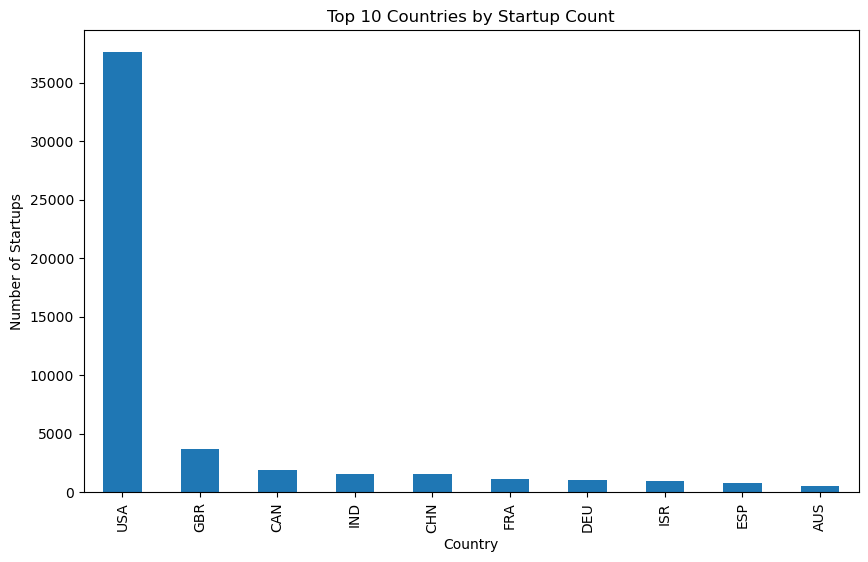

In [54]:
# visualize the geographical distribution of startups
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
df["country_code"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries by Startup Count")
plt.xlabel("Country")
plt.ylabel("Number of Startups")
plt.show()


In [55]:
# Are there any missing values in the country_code column?
df["country_code"].isnull().sum()

np.int64(6958)

In [56]:
# What percentage of startups have missing country information?
df["country_code"].isnull().mean().round(4) * 100

np.float64(10.48)

In [58]:
# Can country_code be directly used in a Machine Learning model?
# Most Machine Learning algorithms cannot understand text directly.Therefore,before model training,categorical variables likecountry_codemust be converted into numerical representations.This process is called Encoding.
# Country is a useful feature, but it requires preprocessing before becoming a Machine Learning input.



In [ ]:
# Should country_code be retained as a feature?
# Yes, country_code should be retained because the geographical location of a startup can significantly influence its growth, funding opportunities, investor availability, government policies, and overall business environment.Although country_code is a categorical feature and contains a few missing values, these issues can be handled during Feature Engineering through appropriate preprocessing and encoding.Therefore, instead of removing this feature, it should be retained for future Machine Learning models.

In [82]:
# What business conclusions can we draw from the country analysis?
# The country analysis reveals that startups in the dataset are not equally distributed across different countries. A few countries contribute the majority of startup records, indicating a geographical imbalance in the dataset.The analysis also shows that country_code is an important business feature because startup ecosystems vary significantly across countries. Although a small number of missing values exist, they can be handled during preprocessing.Overall, country information is expected to play an important role in understanding startup behaviour and should be included in future predictive models.

In [84]:
# What does the category_list feature represent?
# The category_list feature represents the business domain or industry in which a startup operates.It provides information about the products, services, or market sector of a startup, such as Software, Biotechnology, E-Commerce, Artificial Intelligence, Healthcare, and many others.This feature helps us understand the startup ecosystem from an industry perspective and may become an important predictor during Machine Learning.


In [59]:
# How many different startup industries are present?
df["category_list"].nunique()

27296

In [60]:
# Which startup industries have the highest number of startups?
df["category_list"].value_counts().head(10)

category_list
Software               3995
Biotechnology          3615
E-Commerce             1332
Mobile                 1177
Clean Technology       1133
Curated Web            1050
Hardware + Software     932
Health Care             930
Games                   862
Enterprise Software     845
Name: count, dtype: int64

In [61]:
# What percentage of startups belongs to each industry?
df["category_list"].value_counts(normalize=True).mul(100).round(2).head(10)

category_list
Software               6.32
Biotechnology          5.72
E-Commerce             2.11
Mobile                 1.86
Clean Technology       1.79
Curated Web            1.66
Hardware + Software    1.47
Health Care            1.47
Games                  1.36
Enterprise Software    1.34
Name: proportion, dtype: float64

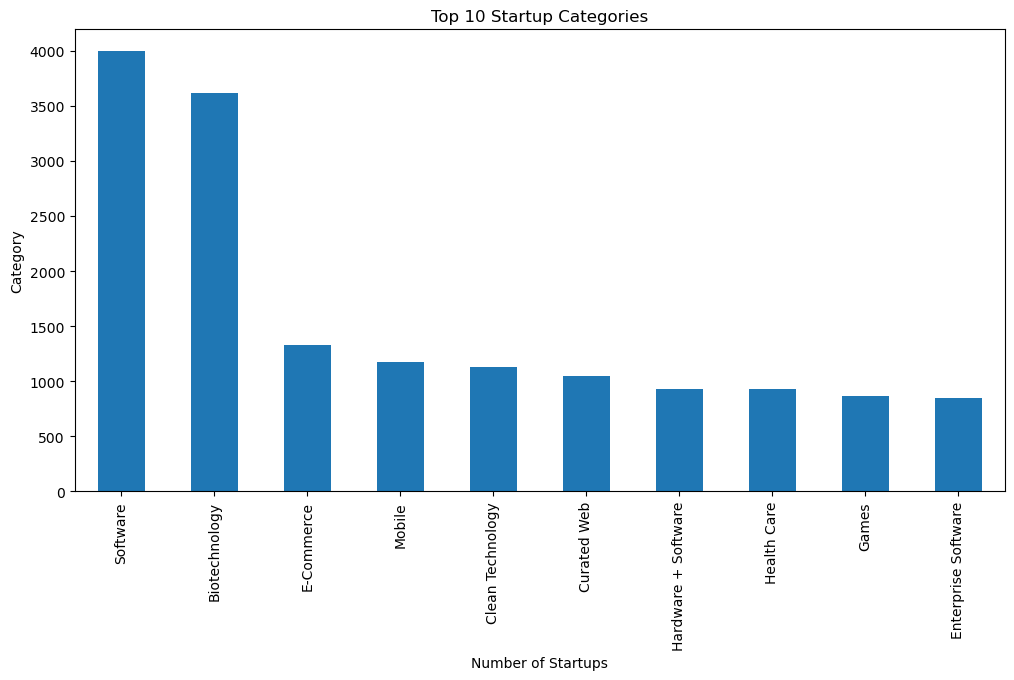

In [63]:
# visualize the top startup industries
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
df["category_list"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Startup Categories")
plt.xlabel("Number of Startups")
plt.ylabel("Category")
plt.show()


In [64]:
# Are there any missing values in the category_list feature?
df["category_list"].isnull().sum()

np.int64(3148)

In [66]:
# What percentage of startups have missing category information?
df["category_list"].isnull().mean().round(4) * 100

np.float64(4.74)

In [ ]:
# Can category_list be directly used in Machine Learning?
# category_list is a complex categorical feature. This feature has valuable business information,but it cannot be used directly.



In [85]:
# Should category_list be retained as a feature?
# Yes, category_list should be retained because the industry in which a startup operates can strongly influence its funding opportunities, customer demand, competition, and growth potential.Although some records contain multiple categories and a few missing values, these issues can be addressed during Feature Engineering by splitting categories, handling missing values, and encoding categorical data.Therefore, this feature should remain in the dataset for further analysis and model development.


In [86]:
# What business conclusions can we draw from startup industry analysis?
# The startup industry analysis shows that the dataset contains startups from a wide range of business sectors, although technology-related industries appear to dominate the dataset.
# The analysis also indicates that industry information is valuable for understanding startup behaviour. Since some startups belong to multiple categories, additional preprocessing will be required before using this feature in Machine Learning.Overall, industry is an important business characteristic and should be retained as a predictive feature.

In [67]:
# What is the overall funding distribution in our dataset?
df["funding_total_usd"].describe()

count    5.358300e+04
mean     1.847860e+07
std      1.880133e+08
min      1.000000e+00
25%      3.356235e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [68]:
# What is the maximum funding received by a startup?
df["funding_total_usd"].max()

30079503000.0

In [69]:
# Which startups received the highest funding?
df["funding_total_usd"].nlargest(10)

61562    3.007950e+10
21584    1.760000e+10
9351     1.066494e+10
60155    8.207450e+09
11608    5.820000e+09
49721    5.800000e+09
10708    5.162513e+09
9354     5.150000e+09
2436     4.812000e+09
43641    4.745460e+09
Name: funding_total_usd, dtype: float64

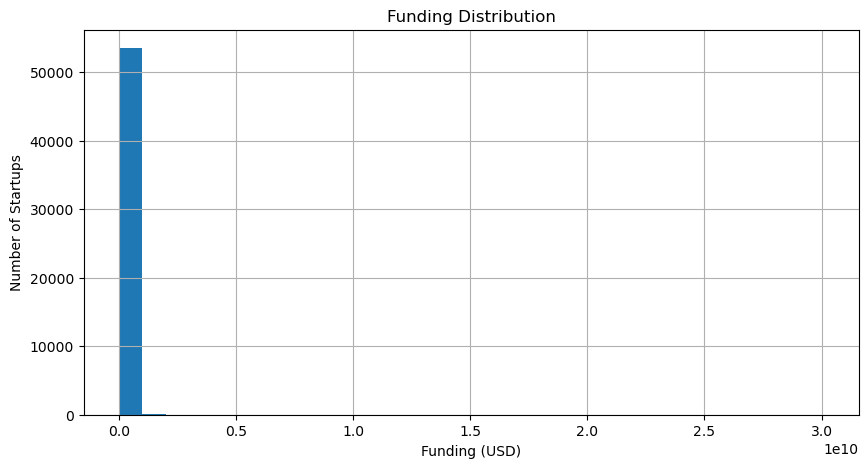

In [70]:
# Is startup funding normally distributed?
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df["funding_total_usd"].hist(bins=30)

plt.title("Funding Distribution")

plt.xlabel("Funding (USD)")

plt.ylabel("Number of Startups")

plt.show()


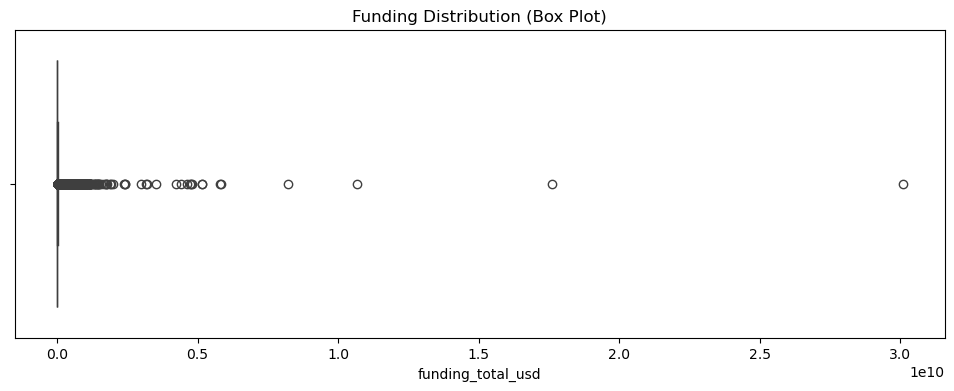

In [71]:
# Are there any funding outliers?
import seaborn as sns

plt.figure(figsize=(12,4))

sns.boxplot(x=df["funding_total_usd"])

plt.title("Funding Distribution (Box Plot)")

plt.show()


In [72]:
# How does average funding differ across startup outcomes?
df.groupby("status")["funding_total_usd"].mean()

status
acquired     2.829304e+07
closed       1.089794e+07
ipo          1.457052e+08
operating    1.392845e+07
Name: funding_total_usd, dtype: float64

In [73]:
# Is the average funding reliable, or should we also examine the median?
df.groupby("status")["funding_total_usd"].median()

status
acquired     10000000.0
closed        1250000.0
ipo          30675796.0
operating     1520832.0
Name: funding_total_usd, dtype: float64

In [74]:
# How do mean and median compare for each startup outcome?
df.groupby("status")["funding_total_usd"].agg(["mean","median"])

,mean,median
status,,
acquired,2.829304e+07,10000000.0
closed,1.089794e+07,1250000.0
ipo,1.457052e+08,30675796.0
operating,1.392845e+07,1520832.0


In [75]:
# How many funding rounds do startups typically raise?
df.groupby("status")["funding_rounds"].agg(["mean","median"])

,mean,median
status,,
acquired,2.116778,2.0
closed,1.399006,1.0
ipo,2.796380,2.0
operating,1.700513,1.0


In [76]:
# What business conclusions can we draw from funding analysis?


In [77]:
# Which features in our dataset are numerical?
numeric_df = df.select_dtypes(include="number")

numeric_df.columns


Index(['funding_total_usd', 'funding_rounds', 'founded_year',
       'first_funding_year', 'last_funding_year'],
      dtype='object')

In [78]:
# Are any numerical features related to each other?
corr_matrix = numeric_df.corr()

corr_matrix


,funding_total_usd,funding_rounds,founded_year,first_funding_year,last_funding_year
funding_total_usd,1.000000,0.112909,-0.069283,-0.056977,-0.002133
funding_rounds,0.112909,1.000000,-0.036023,-0.236724,0.166210
founded_year,-0.069283,-0.036023,1.000000,0.340267,0.311212
first_funding_year,-0.056977,-0.236724,0.340267,1.000000,0.850146
last_funding_year,-0.002133,0.166210,0.311212,0.850146,1.000000


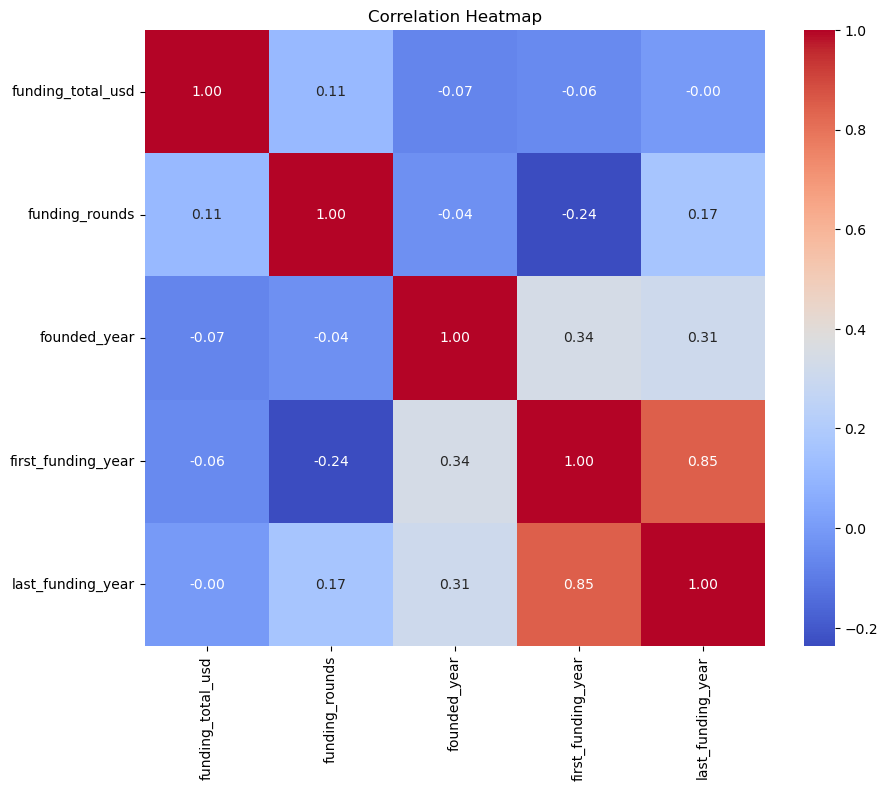

In [79]:
# visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


In [80]:
# Which numerical features are most strongly related to funding?
corr_matrix["funding_total_usd"].sort_values(ascending=False)

funding_total_usd     1.000000
funding_rounds        0.112909
last_funding_year    -0.002133
first_funding_year   -0.056977
founded_year         -0.069283
Name: funding_total_usd, dtype: float64

# What are the major data quality issues discovered during EDA?
During today's EDA, we discovered several important issues.
1. Missing Values
Examples:
•	country_code 
•	category_list 
Some records contain incomplete information.
2. Class Imbalance
Most startups are
Operating
Very few are
IPO
Closed
Acquired
This may affect future Machine Learning models.
3. Funding Outliers
Some startups raised extremely high funding.
These values can influence averages and certain ML algorithms.
4. Multi-Category Values
Some startups belong to multiple industries.
Example
Software|Cloud Computing|AI
This requires preprocessing.


# Which features should be retained for Machine Learning?
Based on today's analysis,the following features appear valuable:
- country_code 
- category_list 
- funding_total_usd 
- funding_rounds 

These features describe:
- Geography 
- Industry 
- Investment 
- Business maturity 
All are likely to influence startup outcomes.


# Which features require Feature Engineering before Machine Learning?

The following features require preprocessing:

Feature	Why?	Planned Action
country_code	Categorical	Encode
category_list	Multi-category text	Split + Encode
funding_total_usd	Highly skewed	Evaluate log transformation
Missing values	Incomplete information	Impute or handle appropriately


# What are the key business insights discovered during EDA?

From today's EDA, we discovered:

Geography
- Startups come from many countries. 
- A few countries dominate the dataset. 

Industry
- Technology-related industries are highly represented. 
- Industry information is valuable for prediction. 

Funding
- Funding is highly skewed. 
- Large funding outliers exist. 
- Funding rounds provide additional business information. 

Startup Outcomes
- Most startups are currently operating. 
- The dataset is imbalanced. 

Data Quality
- Missing values exist. 
- Some features require preprocessing. 


# What are the next steps after Exploratory Data Analysis?

The next stages of the project are:

Step 1 Feature Engineering
- Handle missing values 
- Encode categorical features 
- Process multi-category industries 
- Evaluate funding transformations 

Step 2 Feature Selection
- Choose the most informative variables.

Step 3  Model Building
- Train Machine Learning models.

Step 4  Model Evaluation
- Compare model performance using appropriate evaluation metrics.

Step 5 Explainable AI
- Understand why the model predicts startup failure.

Step 6 Deployment
- Deploy the final prediction system using Streamlit.


# Notebook Summary

In this notebook, we performed **Exploratory Data Analysis (EDA)** to understand the startup dataset before building any Machine Learning models.

We explored the dataset from multiple business perspectives, including **startup outcomes, country distribution, industry categories, funding patterns, and relationships between numerical features**. During the analysis, we identified important characteristics such as **class imbalance, missing values, funding outliers, and skewed funding distribution**.

This analysis also helped us determine which features should be retained for Machine Learning and which features require preprocessing during the **Feature Engineering** stage.

Overall, this notebook provided a clear understanding of the dataset and established a strong foundation for the next phase of the project.

# Key Takeaways

- Understood the overall structure and quality of the startup dataset.
- Identified class imbalance in the `status` feature.
- Analyzed the geographical distribution of startups.
- Explored the most common startup industries.
- Studied funding distribution and detected funding outliers.
- Examined relationships between numerical features using correlation analysis.
- Identified preprocessing tasks required before Machine Learning.

#  Decision Log

| Decision | Reason |
|----------|--------|
| Retained `country_code` | Country may influence startup ecosystem and funding opportunities. |
| Retained `category_list` | Industry information is valuable for prediction. |
| Retained `funding_total_usd` | Funding is an important numerical feature. |
| Missing values not handled | This will be performed during Feature Engineering. |
| Outliers not removed | Need further investigation before preprocessing. |
| Correlated features not removed | Correlation alone is not enough to drop features. |